# 09 — K-Nearest Neighbors

KNN se incorpora como un modelo basado en distancia, distinto de las familias lineal y de árboles. La selección usa solamente datos de 2015–2016; 2017 permanece reservado hasta cerrar la configuración.


## Imports y resolución de la raíz


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)


In [2]:
def find_project_root(start_path=None):
    current = Path(start_path or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del proyecto.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Raíz del proyecto: {PROJECT_ROOT}")


Raíz del proyecto: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026


In [3]:
from src.config import RANDOM_STATE, RAW_DATA_DIR
from src.data import (
    combine_hotel_datasets,
    load_csv_with_fallback,
    make_temporal_holdout_split,
    normalize_text_values,
)
from src.evaluation import (
    evaluate_binary_classifier,
    get_grid_results,
    get_stratified_group_cross_validation,
    run_grid_search,
)
from src.features import (
    build_base_feature_set,
    build_tree_model_feature_sets,
    get_feature_types,
    make_exact_feature_groups,
)
from src.plots import plot_confusion_matrix
from src.preprocessing import build_tabular_preprocessor


## Carga y división temporal


In [4]:
H1_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H1.csv"
H2_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H2.csv"

h1_df = load_csv_with_fallback(RAW_DATA_DIR / "H1.csv", H1_URL)
h2_df = load_csv_with_fallback(RAW_DATA_DIR / "H2.csv", H2_URL)
bookings_df = normalize_text_values(combine_hotel_datasets(h1_df, h2_df))
X_reference, y = build_base_feature_set(bookings_df)
feature_sets = build_tree_model_feature_sets(X_reference)

SELECTED_SET_NAME = "Tree-pruned | 17 features"
X = feature_sets[SELECTED_SET_NAME]
X_train, X_holdout, y_train, y_holdout = make_temporal_holdout_split(
    X,
    y,
    period_values=X_reference["ArrivalDateYear"],
    validation_period=2017,
)

print(f"Conjunto: {SELECTED_SET_NAME}")
print(f"Desarrollo: {X_train.shape}; holdout reservado: {X_holdout.shape}")


Conjunto: Tree-pruned | 17 features
Desarrollo: (78703, 17); holdout reservado: (40687, 17)


## Diseño computacional de la búsqueda

KNN necesita calcular distancias contra muchas observaciones y su costo se concentra en la predicción. Para que el experimento sea ejecutable, la grilla se ajusta sobre una muestra de grupos completos tomada sólo del desarrollo. Se preserva así la separación de duplicados exactos y 2017 no participa en la decisión.

La fracción puede aumentarse si se desea una búsqueda más exhaustiva. El ROC AUC de esta etapa corresponde a la muestra, por lo que no es estrictamente comparable con las CV completas de los demás modelos.


In [5]:
SEARCH_SAMPLE_FRACTION = 0.35

development_groups = make_exact_feature_groups(X_train)
group_sampler = GroupShuffleSplit(
    n_splits=1,
    train_size=SEARCH_SAMPLE_FRACTION,
    random_state=RANDOM_STATE,
)
search_indices, _ = next(
    group_sampler.split(X_train, y_train, groups=development_groups)
)
X_search = X_train.iloc[search_indices].copy()
y_search = y_train.iloc[search_indices].copy()
search_groups = development_groups.iloc[search_indices].copy()

display(pd.DataFrame([
    {
        "dataset": "Desarrollo completo",
        "rows": len(X_train),
        "cancellation_rate": y_train.mean(),
    },
    {
        "dataset": "Muestra de búsqueda",
        "rows": len(X_search),
        "cancellation_rate": y_search.mean(),
    },
]))


,dataset,rows,cancellation_rate
0,Desarrollo completo,78703,0.361854
1,Muestra de búsqueda,27137,0.351734


## Pipeline y grilla acotada


In [6]:
numeric_features, categorical_features = get_feature_types(
    X_train, require_all_categorical=False
)
knn_preprocessor = build_tabular_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    scale_numeric=True,
)
knn_pipeline = Pipeline(steps=[
    ("preprocessor", knn_preprocessor),
    (
        "model",
        KNeighborsClassifier(
            algorithm="brute",
            metric="minkowski",
            p=2,
            n_jobs=1,
        ),
    ),
])

knn_param_grid = {
    "model__n_neighbors": [25, 75],
    "model__weights": ["uniform", "distance"],
}

print(f"Configuraciones: {len(knn_param_grid['model__n_neighbors']) * len(knn_param_grid['model__weights'])}")
print("CV agrupada: 3 folds sobre la muestra de búsqueda")


Configuraciones: 4
CV agrupada: 3 folds sobre la muestra de búsqueda


In [7]:
knn_search_cv = get_stratified_group_cross_validation(n_splits=3)
knn_search = run_grid_search(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    X=X_search,
    y=y_search,
    scoring="roc_auc",
    cv=knn_search_cv,
    groups=search_groups,
    n_jobs=-1,
)

knn_grid_results = get_grid_results(knn_search)
knn_grid_summary = knn_grid_results[[
    "params",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].copy()
knn_grid_summary["train_validation_gap"] = (
    knn_grid_summary["mean_train_score"] - knn_grid_summary["mean_test_score"]
)
display(knn_grid_summary)
print(f"Mejores parámetros: {knn_search.best_params_}")
print(f"ROC AUC CV de búsqueda: {knn_search.best_score_:.6f}")


,params,mean_train_score,mean_test_score,std_test_score,rank_test_score,train_validation_gap
0,"{'model__n_neighbors': 75, 'model__weights': '...",0.999630,0.876338,0.008868,1,0.123292
1,"{'model__n_neighbors': 25, 'model__weights': '...",0.999284,0.874729,0.006511,2,0.124555
2,"{'model__n_neighbors': 25, 'model__weights': '...",0.930600,0.872464,0.006452,3,0.058136
3,"{'model__n_neighbors': 75, 'model__weights': '...",0.906564,0.870822,0.007869,4,0.035742


Mejores parámetros: {'model__n_neighbors': 75, 'model__weights': 'distance'}
ROC AUC CV de búsqueda: 0.876338


## Evaluación única sobre 2017

La configuración elegida en la muestra se reajusta ahora con todo 2015–2016. Esta celda puede demorar porque la predicción exige calcular las distancias de cada reserva de 2017 contra el conjunto de desarrollo.


In [8]:
final_knn_model = knn_pipeline.set_params(**knn_search.best_params_)
final_knn_model.fit(X_train, y_train)
knn_holdout_metrics = evaluate_binary_classifier(
    final_knn_model, X_holdout, y_holdout, threshold=0.5
)

knn_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression engineered",
        "holdout_roc_auc": 0.855017,
        "accuracy": 0.739032,
        "precision": 0.620290,
        "recall": 0.839568,
        "f1": 0.713461,
    },
    {
        "model": "XGBoost regularized",
        "holdout_roc_auc": 0.867291,
        "accuracy": 0.781724,
        "precision": 0.737476,
        "recall": 0.676913,
        "f1": 0.705898,
    },
    {
        "model": "KNN",
        "holdout_roc_auc": knn_holdout_metrics["roc_auc"],
        "accuracy": knn_holdout_metrics["accuracy"],
        "precision": knn_holdout_metrics["precision"],
        "recall": knn_holdout_metrics["recall"],
        "f1": knn_holdout_metrics["f1"],
    },
]).set_index("model")
display(knn_comparison)


,holdout_roc_auc,accuracy,precision,recall,f1
model,,,,,
Logistic Regression engineered,0.855017,0.739032,0.620290,0.839568,0.713461
XGBoost regularized,0.867291,0.781724,0.737476,0.676913,0.705898
KNN,0.825042,0.759751,0.743475,0.578914,0.650955


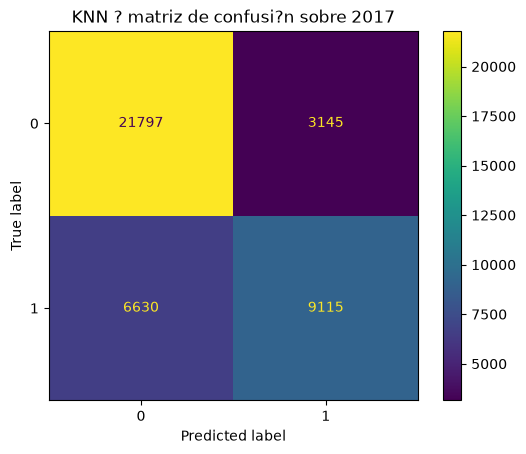

In [9]:
plot_confusion_matrix(
    final_knn_model, X_holdout, y_holdout,
    title="KNN — matriz de confusión sobre 2017",
)


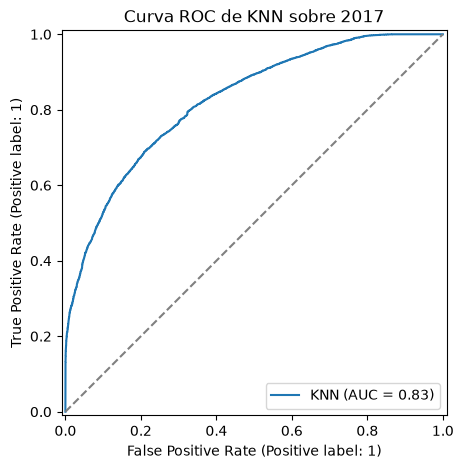

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(
    final_knn_model,
    X_holdout,
    y_holdout,
    name="KNN",
    ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_title("Curva ROC de KNN sobre 2017")
plt.show()


## Conclusiones

La búsqueda acotada seleccionó 75 vecinos con ponderación por distancia. Sobre la muestra agrupada de desarrollo alcanzó ROC AUC CV 0,876338, con desviación 0,008868. Este valor no es directamente comparable con las CV completas de los demás modelos porque la búsqueda se realizó sobre 27.137 reservas y tres folds para limitar el costo de cálculo.

El ROC AUC de entrenamiento cercano a 1 de las configuraciones ponderadas por distancia no se interpreta como una estimación convencional de ajuste: al predecir sobre el propio entrenamiento, cada observación aparece como vecina a distancia cero y domina su resultado. La evidencia relevante para comparar configuraciones es la validación y, una vez cerrada la selección, el holdout temporal.

Sobre 2017, KNN obtuvo ROC AUC 0,825042, Accuracy 0,759751, Precision 0,743475, Recall 0,578914 y F1 0,650955. La Precision es competitiva, pero el modelo omite más de cuatro de cada diez cancelaciones y presenta el menor ROC AUC temporal entre los modelos entrenados.

El resultado es coherente con las limitaciones de las distancias en un espacio de alta dimensión producido por One-Hot Encoding. Ajustar el threshold podría alterar Precision y Recall, pero no corregiría la menor capacidad de ordenamiento reflejada por ROC AUC. Por ello no se amplía la grilla: KNN cumple el objetivo de comparar una familia basada en distancia, pero no se considera candidato final.
